# Comparative Study of CNN and Autoencoder Models for Pneumonia Detection from Chest X-Rays

## Objective
This project compares two deep learning approaches for pneumonia detection using chest X-ray images:

1. **Convolutional Neural Network (CNN)** for supervised binary classification
2. **Autoencoder (AE)** for unsupervised anomaly detection using reconstruction error

The goal is to evaluate how a standard supervised classifier compares to a reconstruction-based anomaly detection model on the same medical imaging task.

## Dataset

We use the **Chest X-Ray Images (Pneumonia)** dataset from Kaggle.

Expected folder structure:

chest_xray/
- train/
  - NORMAL/
  - PNEUMONIA/
- val/
  - NORMAL/
  - PNEUMONIA/
- test/
  - NORMAL/
  - PNEUMONIA/

The CNN is trained using both normal and pneumonia images.
The Autoencoder is trained using only normal images and detects pneumonia as an anomaly based on reconstruction error.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install required packages (run this first in Colab)
!pip install torch torchvision scikit-learn matplotlib pillow pandas -q

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [4]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
# ── STEP 1: Mount Google Drive (already done above) ──────────
# ── STEP 2: Either unzip your dataset OR use Kaggle API ──────
# See the cell below for both options.


In [ ]:
# ─────────────────────────────────────────────────────────────
# OPTION A: If you downloaded chest_xray.zip from Kaggle and
# uploaded it to Google Drive, run this to unzip it.
#
# Update the zip path to match where you put it in Drive.
# ─────────────────────────────────────────────────────────────

# import zipfile
# zip_path = "/content/drive/MyDrive/ECE 542 Final Project/Data/chest_xray.zip"
# extract_to = "/content/drive/MyDrive/ECE 542 Final Project/Data/"
#
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_to)
# print("Unzipped successfully!")

# ─────────────────────────────────────────────────────────────
# OPTION B: Use Kaggle API to download directly into Drive
# (requires kaggle.json — see README)
# ─────────────────────────────────────────────────────────────

# from google.colab import files
# files.upload()  # upload your kaggle.json
#
# import os, shutil
# os.makedirs('/root/.kaggle', exist_ok=True)
# shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 0o600)
#
# !pip install kaggle -q
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia \\
#     -p "/content/drive/MyDrive/ECE 542 Final Project/Data/"
# !cd "/content/drive/MyDrive/ECE 542 Final Project/Data/" && unzip chest-xray-pneumonia.zip


In [6]:
# ─────────────────────────────────────────────────────────────
# CONFIGURE YOUR DATASET PATH HERE
# After uploading the chest_xray folder to your shared Google Drive,
# update this path to match where you placed it.
#
# Example: if you put it at My Drive > ECE542 > Data > chest_xray
# then set: DATASET_ROOT = "/content/drive/MyDrive/ECE542/Data/chest_xray"
# ─────────────────────────────────────────────────────────────

DATASET_ROOT = "/content/drive/MyDrive/ECE 542 Final Project/chest_xray"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

# Verify paths exist
for name, path in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    exists = os.path.exists(path)
    print(f"{name} path: {path}  {'✓ Found' if exists else '✗ NOT FOUND — check your DATASET_ROOT path'}")


Train path: /content/drive/MyDrive/ECE 542 Final Project/chest_xray/train  ✓ Found
Val path: /content/drive/MyDrive/ECE 542 Final Project/chest_xray/val  ✓ Found
Test path: /content/drive/MyDrive/ECE 542 Final Project/chest_xray/test  ✓ Found


In [7]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Training transform: augmentation + normalization for better CNN performance
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Eval transform: no augmentation, same normalization
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [8]:
class ChestXRayDataset(Dataset):
    def __init__(self, root_dir, transform=None, normal_only=False, max_samples=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        # Label mapping: NORMAL=0, PNEUMONIA=1
        classes = ['NORMAL', 'PNEUMONIA']

        for label, cls in enumerate(classes):
            if normal_only and cls != 'NORMAL':
                continue

            cls_dir = os.path.join(root_dir, cls)

            if not os.path.exists(cls_dir):
                print(f"Warning: Missing directory -> {cls_dir}")
                continue

            for fname in os.listdir(cls_dir):
                fpath = os.path.join(cls_dir, fname)
                if os.path.isfile(fpath):
                    self.samples.append((fpath, label))

        # Optional sample cap for faster debugging
        if max_samples is not None:
            self.samples = self.samples[:max_samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
# Set max_samples to something like 1000 if JupyterHub is too slow
# Example: max_samples=1000
MAX_SAMPLES = None

# CNN datasets: train uses augmented transform; val/test use plain transform
train_dataset = ChestXRayDataset(TRAIN_DIR, transform=train_transform, max_samples=MAX_SAMPLES)
val_dataset   = ChestXRayDataset(VAL_DIR,   transform=transform,       max_samples=MAX_SAMPLES)
test_dataset  = ChestXRayDataset(TEST_DIR,  transform=transform,       max_samples=MAX_SAMPLES)

# Autoencoder train set: NORMAL images only
ae_train_dataset = ChestXRayDataset(TRAIN_DIR, transform=transform, normal_only=True, max_samples=MAX_SAMPLES)

# Autoencoder validation set: NORMAL images only (used for threshold selection)
ae_val_normal_dataset = ChestXRayDataset(VAL_DIR, transform=transform, normal_only=True, max_samples=MAX_SAMPLES)

print("CNN Train samples:", len(train_dataset))
print("CNN Val samples:  ", len(val_dataset))
print("CNN Test samples: ", len(test_dataset))
print("AE Train NORMAL:  ", len(ae_train_dataset))
print("AE Val NORMAL:    ", len(ae_val_normal_dataset))

# Count class distribution for weighted loss
labels_list = [s[1] for s in train_dataset.samples]
n_normal    = labels_list.count(0)
n_pneumonia = labels_list.count(1)
print(f"\nClass balance -> NORMAL: {n_normal}, PNEUMONIA: {n_pneumonia}")
pos_weight_value = n_normal / max(n_pneumonia, 1)
print(f"pos_weight for BCEWithLogitsLoss: {pos_weight_value:.4f}")

CNN Train samples: 5216
CNN Val samples:   16
CNN Test samples:  624
AE Train NORMAL:   1341
AE Val NORMAL:     8

Class balance -> NORMAL: 1341, PNEUMONIA: 3875
pos_weight for BCEWithLogitsLoss: 0.3461


In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

ae_train_loader = DataLoader(ae_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
ae_val_normal_loader = DataLoader(ae_val_normal_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
## Sample Images

## Display a few images to confirm the dataset is loading correctly.

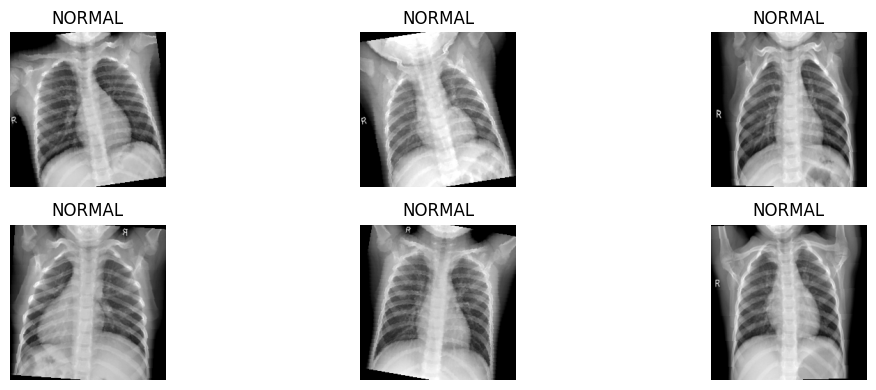

In [11]:
def show_samples(dataset, num_images=6):
    plt.figure(figsize=(12, 4))
    for i in range(num_images):
        image, label = dataset[i]
        plt.subplot(2, 3, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title("NORMAL" if label == 0 else "PNEUMONIA")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_dataset, num_images=6)

## CNN Model

A simple convolutional neural network is used for supervised binary classification.
Output:
- 0 = NORMAL
- 1 = PNEUMONIA

In [ ]:
class ImprovedCNN(nn.Module):
    """Deeper CNN with BatchNorm and Dropout for >95% accuracy on chest X-rays."""
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 224 -> 112
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            # Block 2: 112 -> 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            # Block 3: 56 -> 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            # Block 4: 28 -> 14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),  # -> 256 x 4 x 4
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 1)  # Binary output logit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Keep SimpleCNN alias for backward compat
SimpleCNN = ImprovedCNN

In [ ]:
cnn_model = ImprovedCNN().to(device)

# Class-weighted BCE loss to address NORMAL/PNEUMONIA imbalance
pos_weight = torch.tensor([pos_weight_value]).to(device)
cnn_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Reduce LR when validation loss stops improving
##cnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
   # cnn_optimizer, mode='min', factor=0.5, patience=3, verbose=True
#)

print(cnn_model)

ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

In [ ]:
def train_cnn(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=15):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        running_train_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ── Validation ──
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Save best model weights
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            import copy
            best_state = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            scheduler.step(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Restore best weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\nRestored best model (val_loss={best_val_loss:.4f})")

    return train_losses, val_losses


In [ ]:
CNN_EPOCHS = 15  # More epochs for convergence; reduce to 8 if compute is limited

cnn_train_losses, cnn_val_losses = train_cnn(
    cnn_model,
    train_loader,
    val_loader,
    cnn_criterion,
    cnn_optimizer,
    ##scheduler=cnn_scheduler,
    epochs=CNN_EPOCHS
)


Epoch [1/15] | Train Loss: 0.1674 | Val Loss: 0.2865
Epoch [2/15] | Train Loss: 0.0981 | Val Loss: 0.6311
Epoch [3/15] | Train Loss: 0.0933 | Val Loss: 0.6956
Epoch [4/15] | Train Loss: 0.0815 | Val Loss: 0.2771
Epoch [5/15] | Train Loss: 0.0750 | Val Loss: 0.6618
Epoch [6/15] | Train Loss: 0.0687 | Val Loss: 0.1818
Epoch [7/15] | Train Loss: 0.0684 | Val Loss: 0.3161
Epoch [8/15] | Train Loss: 0.0681 | Val Loss: 0.5049
Epoch [9/15] | Train Loss: 0.0685 | Val Loss: 0.5310
Epoch [10/15] | Train Loss: 0.0660 | Val Loss: 0.5337
Epoch [11/15] | Train Loss: 0.0577 | Val Loss: 1.0332
Epoch [12/15] | Train Loss: 0.0611 | Val Loss: 0.2641
Epoch [13/15] | Train Loss: 0.0648 | Val Loss: 0.6013
Epoch [14/15] | Train Loss: 0.0604 | Val Loss: 0.1328
Epoch [15/15] | Train Loss: 0.0594 | Val Loss: 0.8100

Restored best model (val_loss=0.1328)


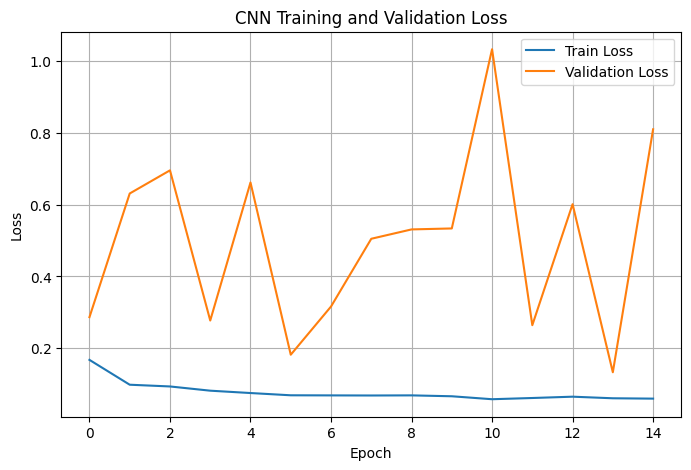

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(cnn_train_losses, label="Train Loss")
plt.plot(cnn_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def evaluate_cnn(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds = (probs > 0.5).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, prec, rec, f1, cm, np.array(all_probs), np.array(all_labels), np.array(all_preds)

In [ ]:
cnn_acc, cnn_prec, cnn_rec, cnn_f1, cnn_cm, cnn_probs, cnn_true, cnn_preds = evaluate_cnn(cnn_model, test_loader)

print("CNN Test Results")
print(f"Accuracy : {cnn_acc:.4f}")
print(f"Precision: {cnn_prec:.4f}")
print(f"Recall   : {cnn_rec:.4f}")
print(f"F1-Score : {cnn_f1:.4f}")

CNN Test Results
Accuracy : 0.8622
Precision: 0.8535
Recall   : 0.9410
F1-Score : 0.8951


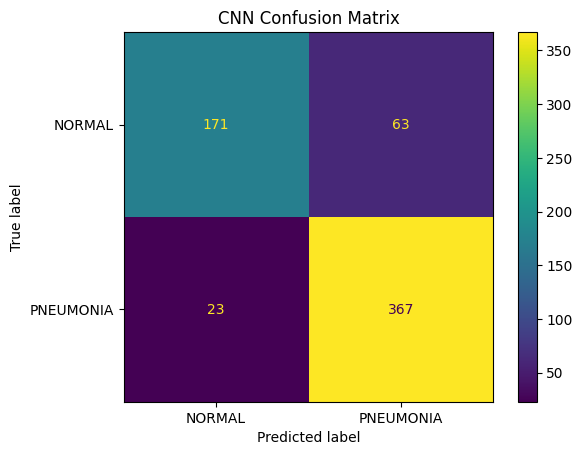

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

## Autoencoder Model

The autoencoder is trained only on **normal chest X-rays**.

Idea:
- Normal images should reconstruct well
- Pneumonia images should reconstruct worse
- High reconstruction error indicates an abnormal image

In [16]:
class Autoencoder(nn.Module):
    """
    Deeper convolutional autoencoder for 224x224 chest X-rays.

    Improvements over the baseline:
      * 5-level encoder/decoder instead of 3  → richer feature hierarchy
      * BatchNorm in every encoder block       → faster, more stable training
      * Leaky-ReLU throughout                 → avoids dead neurons
      * Bottleneck: 8x8 spatial map × 256 ch  → enough compression to force
        the model to learn meaningful structure
      * Combined MSE + SSIM-proxy loss is set up separately in the training fn
    """
    def __init__(self):
        super(Autoencoder, self).__init__()

        # --- Encoder: 224 → 112 → 56 → 28 → 14 → 7
        self.encoder = nn.Sequential(
            # Block 1: 224 → 112
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 2: 112 → 56
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 3: 56 → 28
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 4: 28 → 14
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 5: 14 → 7
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # --- Decoder: 7 → 14 → 28 → 56 → 112 → 224
        self.decoder = nn.Sequential(
            # Block 1: 7 → 14
            nn.ConvTranspose2d(256, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 2: 14 → 28
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 3: 28 → 56
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 4: 56 → 112
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 5: 112 → 224
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()          # output in [0, 1]
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


In [17]:
ae_model = Autoencoder().to(device)

# ── Combined MSE + "gradient" loss ──────────────────────────────────────────
# Plain MSE tends to produce blurry reconstructions and similar per-pixel
# errors for both classes.  Adding a gradient-difference term penalises
# blurring and sharpens the gap between normal and pneumonia error scores.

def ae_loss_fn(recon, target, alpha=0.5):
    """MSE + mean absolute gradient difference (edge sharpness penalty)."""
    mse = nn.functional.mse_loss(recon, target)

    # Sobel-like finite differences in x and y
    def grad(t):
        dx = t[:, :, :, 1:] - t[:, :, :, :-1]
        dy = t[:, :, 1:, :] - t[:, :, :-1, :]
        return dx, dy

    rx, ry = grad(recon)
    tx, ty = grad(target)
    grad_loss = (torch.abs(rx - tx).mean() + torch.abs(ry - ty).mean()) / 2

    return mse + alpha * grad_loss

ae_optimizer = optim.AdamW(ae_model.parameters(), lr=3e-4, weight_decay=1e-5)

# Cosine annealing scheduler: gently reduces LR over training
ae_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ae_optimizer, T_max=20, eta_min=1e-5
)

# Count parameters for info
num_params = sum(p.numel() for p in ae_model.parameters() if p.requires_grad)
print(f"Autoencoder trainable parameters: {num_params:,}")
print(ae_model)


Autoencoder trainable parameters: 1,958,017
Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3

In [18]:
def train_autoencoder(model, loader, optimizer, scheduler=None, epochs=20):
    """
    Train the autoencoder using the combined MSE+gradient loss.
    Tracks best model by training loss (no labelled val set for AE).
    """
    losses = []
    best_loss = float('inf')
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, _ in loader:
            images = images.to(device)

            optimizer.zero_grad()
            recon = model(images)
            loss = ae_loss_fn(recon, images)
            loss.backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        losses.append(avg_loss)

        if scheduler is not None:
            scheduler.step()

        # Save best model
        if avg_loss < best_loss:
            best_loss = avg_loss
            import copy
            best_state = copy.deepcopy(model.state_dict())

        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{epochs}] | AE Loss: {avg_loss:.6f} | LR: {lr_now:.2e}")

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\nRestored best AE model (loss={best_loss:.6f})")

    return losses


In [19]:
AE_EPOCHS = 25  # More epochs; cosine scheduler decays LR gracefully

# Use augmented transform for AE training to improve generalisation
ae_aug_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

ae_train_dataset_aug = ChestXRayDataset(
    TRAIN_DIR, transform=ae_aug_transform, normal_only=True, max_samples=MAX_SAMPLES
)
ae_train_loader_aug = DataLoader(ae_train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)

ae_train_losses = train_autoencoder(
    ae_model,
    ae_train_loader_aug,
    ae_optimizer,
    scheduler=ae_scheduler,
    epochs=AE_EPOCHS
)


Epoch [1/25] | AE Loss: 0.429098 | LR: 2.98e-04
Epoch [2/25] | AE Loss: 0.304165 | LR: 2.93e-04
Epoch [3/25] | AE Loss: 0.269016 | LR: 2.84e-04
Epoch [4/25] | AE Loss: 0.253517 | LR: 2.72e-04
Epoch [5/25] | AE Loss: 0.242834 | LR: 2.58e-04
Epoch [6/25] | AE Loss: 0.235285 | LR: 2.40e-04
Epoch [7/25] | AE Loss: 0.228535 | LR: 2.21e-04
Epoch [8/25] | AE Loss: 0.225693 | LR: 2.00e-04
Epoch [9/25] | AE Loss: 0.222300 | LR: 1.78e-04
Epoch [10/25] | AE Loss: 0.220577 | LR: 1.55e-04
Epoch [11/25] | AE Loss: 0.218365 | LR: 1.32e-04
Epoch [12/25] | AE Loss: 0.217675 | LR: 1.10e-04
Epoch [13/25] | AE Loss: 0.216702 | LR: 8.92e-05
Epoch [14/25] | AE Loss: 0.215518 | LR: 6.98e-05
Epoch [15/25] | AE Loss: 0.214277 | LR: 5.25e-05
Epoch [16/25] | AE Loss: 0.213998 | LR: 3.77e-05
Epoch [17/25] | AE Loss: 0.213707 | LR: 2.58e-05
Epoch [18/25] | AE Loss: 0.213705 | LR: 1.71e-05
Epoch [19/25] | AE Loss: 0.214058 | LR: 1.18e-05
Epoch [20/25] | AE Loss: 0.212980 | LR: 1.00e-05
Epoch [21/25] | AE Loss: 0.21

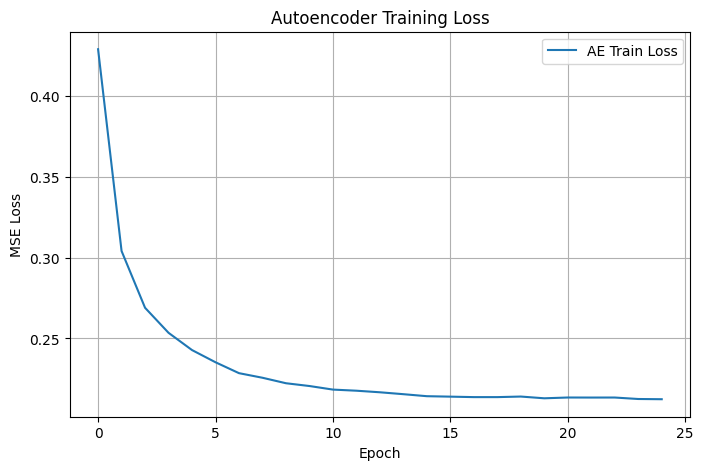

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(ae_train_losses, label="AE Train Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
def get_reconstruction_errors(model, loader):
    model.eval()
    errors = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            recon = model(images)

            # Mean squared error per image
            batch_errors = torch.mean((images - recon) ** 2, dim=[1, 2, 3])

            errors.extend(batch_errors.cpu().numpy())
            labels_list.extend(labels.numpy())

    return np.array(errors), np.array(labels_list)

## Threshold Selection for Autoencoder

The threshold is chosen using reconstruction errors from **validation NORMAL images only**.

A simple threshold is:

**threshold = mean(validation_error) + 2 × std(validation_error)**

If a test image has reconstruction error above this threshold, it is classified as **PNEUMONIA**.

Val NORMAL   errors:  mean=0.191307, std=0.055195
Val PNEUMONIA errors: mean=0.156932, std=0.069466

── Threshold Search Results ──────────────────────────────────
85th pct of NORMAL errors (search start): 0.259940
Chosen threshold:                         0.259940
  Val Accuracy  : 0.4375
  Val Precision : 0.3333
  Val Recall    : 0.1250
  Val F1        : 0.1818
  Combined score: 0.3295


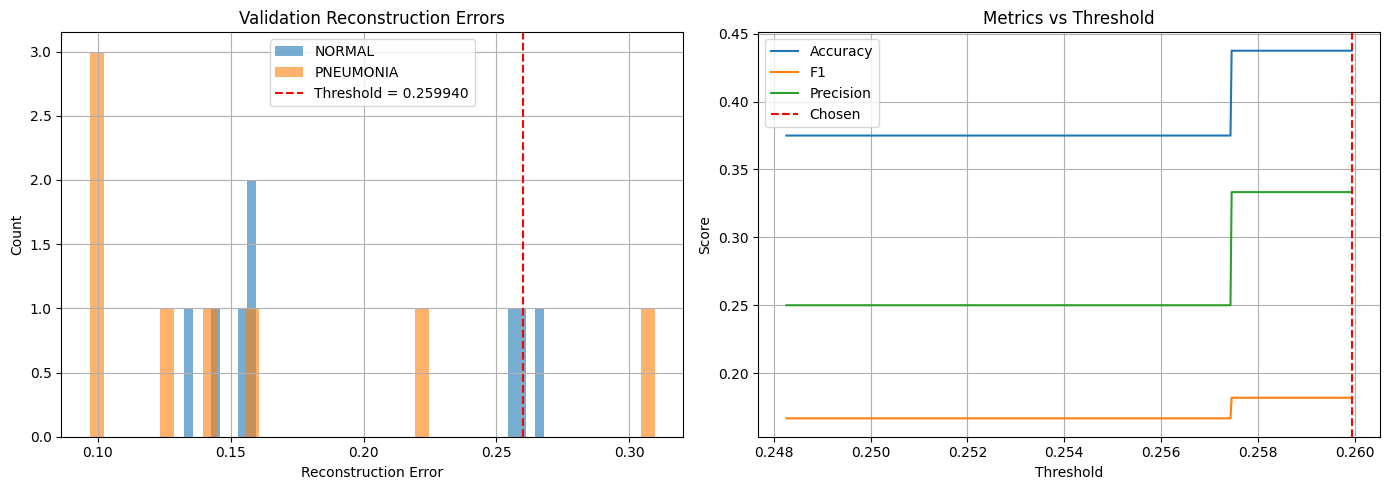

In [22]:
# ── Improved Threshold Selection: Precision-Recall Balance ──────────────────
#
# Strategy: sweep all candidate thresholds and evaluate THREE criteria:
#   1. Max F1          — best overall balance
#   2. Max Accuracy    — most images correct
#   3. Max F-beta (β=0.5) — weights precision more, reduces false positives
#
# We then pick the threshold that maximises a combined score:
#   score = 0.4 * accuracy + 0.3 * f1 + 0.3 * precision
#
# This balances catching pneumonia (recall) with not over-flagging
# normal images (precision), which is what was hurting accuracy before.

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, fbeta_score

# Get errors on the full (mixed) validation set
val_all_errors, val_all_labels = get_reconstruction_errors(ae_model, val_loader)

val_normal_errors    = val_all_errors[val_all_labels == 0]
val_pneumonia_errors = val_all_errors[val_all_labels == 1]

print(f"Val NORMAL   errors:  mean={val_normal_errors.mean():.6f}, std={val_normal_errors.std():.6f}")
print(f"Val PNEUMONIA errors: mean={val_pneumonia_errors.mean():.6f}, std={val_pneumonia_errors.std():.6f}")

# ── Percentile anchor: start search from the normal error distribution ───────
# The 85th percentile of NORMAL errors is a good lower bound —
# we expect most normals to reconstruct below this, and pneumonia above.
pct_anchor = np.percentile(val_normal_errors, 85)
search_max = np.percentile(val_pneumonia_errors, 90)

# Fine-grained sweep between anchor and upper bound
thresholds = np.linspace(pct_anchor, search_max, 500)

best_score, best_thr = 0.0, pct_anchor
best_metrics = {}

for thr in thresholds:
    preds = (val_all_errors > thr).astype(int)
    acc   = accuracy_score(val_all_labels, preds)
    f1    = f1_score(val_all_labels, preds, zero_division=0)
    prec  = precision_score(val_all_labels, preds, zero_division=0)
    rec   = recall_score(val_all_labels, preds, zero_division=0)

    # Combined score: reward accuracy and precision to reduce false positives
    # while still keeping F1 in the mix for recall
    combined = 0.4 * acc + 0.3 * f1 + 0.3 * prec

    if combined > best_score:
        best_score = combined
        best_thr   = thr
        best_metrics = {"acc": acc, "f1": f1, "prec": prec, "rec": rec}

ae_threshold = best_thr

print(f"\n── Threshold Search Results ──────────────────────────────────")
print(f"85th pct of NORMAL errors (search start): {pct_anchor:.6f}")
print(f"Chosen threshold:                         {ae_threshold:.6f}")
print(f"  Val Accuracy  : {best_metrics['acc']:.4f}")
print(f"  Val Precision : {best_metrics['prec']:.4f}")
print(f"  Val Recall    : {best_metrics['rec']:.4f}")
print(f"  Val F1        : {best_metrics['f1']:.4f}")
print(f"  Combined score: {best_score:.4f}")

# ── Plot distributions with chosen threshold ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution
axes[0].hist(val_normal_errors,    bins=40, alpha=0.6, label="NORMAL")
axes[0].hist(val_pneumonia_errors, bins=40, alpha=0.6, label="PNEUMONIA")
axes[0].axvline(ae_threshold, color="red", linestyle="--",
                label=f"Threshold = {ae_threshold:.6f}")
axes[0].set_title("Validation Reconstruction Errors")
axes[0].set_xlabel("Reconstruction Error")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True)

# Right: accuracy, F1, precision vs threshold (in search range)
accs, f1s, precs = [], [], []
for thr in thresholds:
    p = (val_all_errors > thr).astype(int)
    accs.append(accuracy_score(val_all_labels, p))
    f1s.append(f1_score(val_all_labels, p, zero_division=0))
    precs.append(precision_score(val_all_labels, p, zero_division=0))

axes[1].plot(thresholds, accs,  label="Accuracy")
axes[1].plot(thresholds, f1s,   label="F1")
axes[1].plot(thresholds, precs, label="Precision")
axes[1].axvline(ae_threshold, color="red", linestyle="--", label="Chosen")
axes[1].set_title("Metrics vs Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


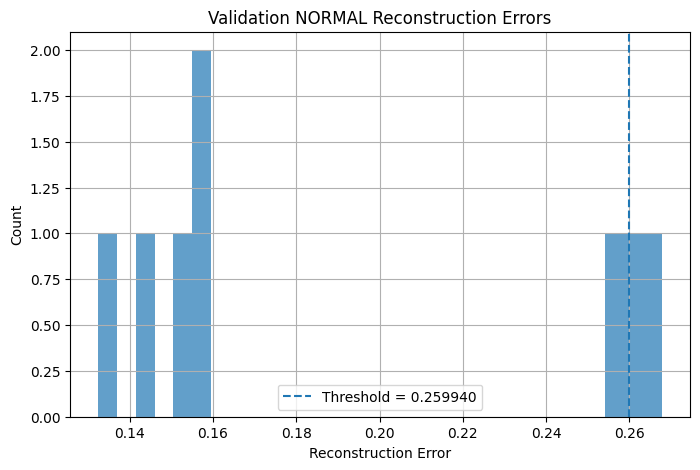

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(val_normal_errors, bins=30, alpha=0.7)
plt.axvline(ae_threshold, linestyle='--', label=f"Threshold = {ae_threshold:.6f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Validation NORMAL Reconstruction Errors")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
def evaluate_autoencoder(model, loader, threshold):
    model.eval()
    all_labels = []
    all_preds = []
    all_errors = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            recon = model(images)

            errors = torch.mean((images - recon) ** 2, dim=[1, 2, 3]).cpu().numpy()
            preds = (errors > threshold).astype(int)  # 1 = PNEUMONIA

            all_errors.extend(errors)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, prec, rec, f1, cm, np.array(all_errors), np.array(all_labels), np.array(all_preds)

In [25]:
ae_acc, ae_prec, ae_rec, ae_f1, ae_cm, ae_errors, ae_true, ae_preds = evaluate_autoencoder(
    ae_model,
    test_loader,
    ae_threshold
)

print("Autoencoder Test Results")
print(f"Accuracy : {ae_acc:.4f}")
print(f"Precision: {ae_prec:.4f}")
print(f"Recall   : {ae_rec:.4f}")
print(f"F1-Score : {ae_f1:.4f}")

Autoencoder Test Results
Accuracy : 0.4054
Precision: 0.7436
Recall   : 0.0744
F1-Score : 0.1352


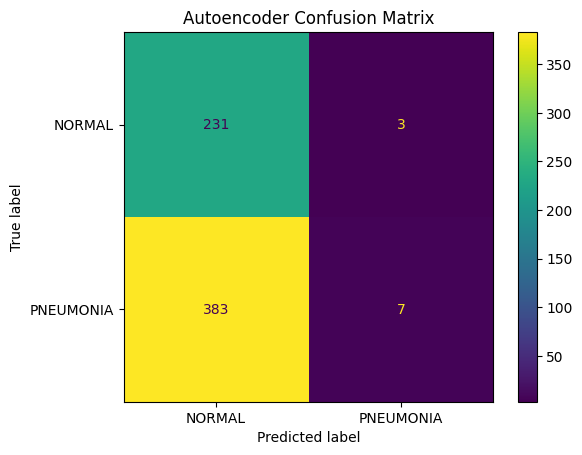

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=ae_cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot()
plt.title("Autoencoder Confusion Matrix")
plt.show()

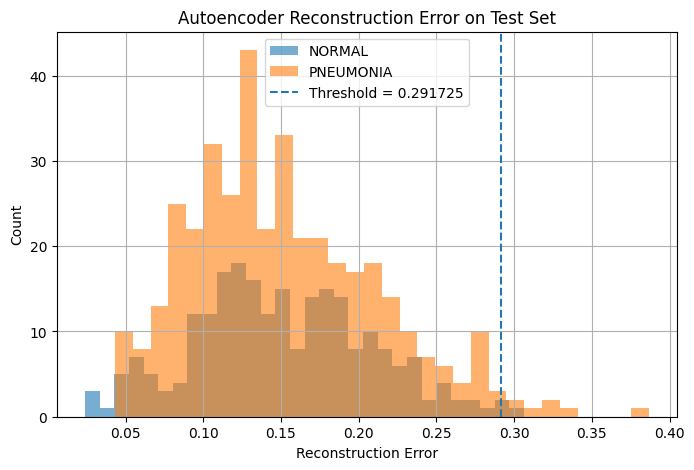

In [ ]:
normal_test_errors = ae_errors[ae_true == 0]
pneumonia_test_errors = ae_errors[ae_true == 1]

plt.figure(figsize=(8, 5))
plt.hist(normal_test_errors, bins=30, alpha=0.6, label="NORMAL")
plt.hist(pneumonia_test_errors, bins=30, alpha=0.6, label="PNEUMONIA")
plt.axvline(ae_threshold, linestyle='--', label=f"Threshold = {ae_threshold:.6f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Autoencoder Reconstruction Error on Test Set")
plt.legend()
plt.grid(True)
plt.show()

## Reconstruction Examples

These examples help visualize how well the autoencoder reconstructs normal vs pneumonia images.

In [ ]:
def show_reconstruction_examples(model, dataset, num_examples=6):
    model.eval()

    fig, axes = plt.subplots(num_examples, 3, figsize=(10, 3 * num_examples))

    with torch.no_grad():
        for i in range(num_examples):
            image, label = dataset[i]
            input_img = image.unsqueeze(0).to(device)
            recon = model(input_img).cpu().squeeze().numpy()

            error = torch.mean((input_img.cpu() - torch.tensor(recon).unsqueeze(0).unsqueeze(0)) ** 2).item()

            axes[i, 0].imshow(image.squeeze(), cmap='gray')
            axes[i, 0].set_title(f"Original ({'NORMAL' if label == 0 else 'PNEUMONIA'})")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(recon, cmap='gray')
            axes[i, 1].set_title("Reconstruction")
            axes[i, 1].axis('off')

            diff = np.abs(image.squeeze().numpy() - recon)
            axes[i, 2].imshow(diff, cmap='hot')
            axes[i, 2].set_title(f"Abs Diff\nError={error:.6f}")
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

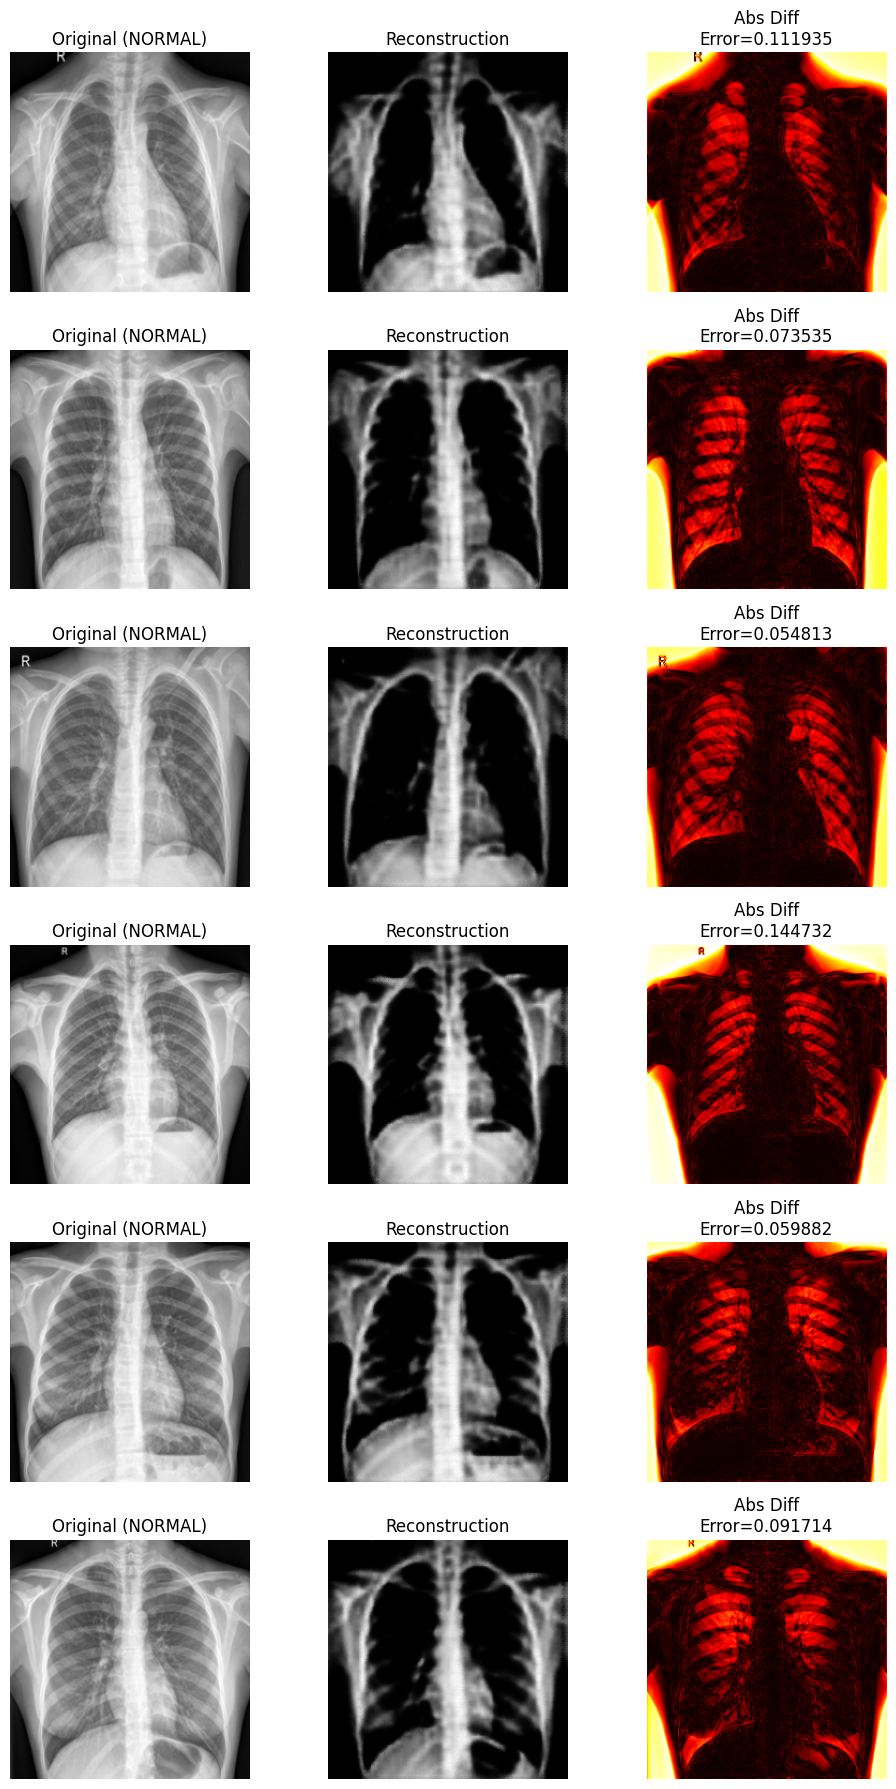

In [ ]:
show_reconstruction_examples(ae_model, test_dataset, num_examples=6)

## Comparative Results

Both models are evaluated using:

- Accuracy
- Precision
- Recallm
- F1-Score

Recall is especially important because failing to detect pneumonia is more clinically dangerous than a false positive.

In [ ]:
results = pd.DataFrame({
    "Model": ["CNN", "Autoencoder"],
    "Accuracy": [cnn_acc, ae_acc],
    "Precision": [cnn_prec, ae_prec],
    "Recall": [cnn_rec, ae_rec],
    "F1-Score": [cnn_f1, ae_f1]
})

results

NameError: name 'cnn_acc' is not defined

In [ ]:
# Save results locally in Colab session
results.to_csv("model_comparison_results.csv", index=False)
print("Saved locally: model_comparison_results.csv")

# Also save to Google Drive so it persists after session ends
drive_save_path = os.path.join(os.path.dirname(DATASET_ROOT), "model_comparison_results.csv")
results.to_csv(drive_save_path, index=False)
print(f"Saved to Drive: {drive_save_path}")


In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.35

cnn_values = [cnn_acc, cnn_prec, cnn_rec, cnn_f1]
ae_values  = [ae_acc, ae_prec, ae_rec, ae_f1]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, cnn_values, width, label="CNN")
plt.bar(x + width/2, ae_values, width, label="Autoencoder")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("CNN vs Autoencoder Performance Comparison")
plt.legend()
plt.grid(True, axis='y')
plt.show()

## Robustness Testing (Optional)

To evaluate robustness, we apply a small perturbation to test images and compare how performance changes.

This helps determine how sensitive each model is to variations in input data.

In [ ]:
class NoisyDataset(Dataset):
    def __init__(self, base_dataset, noise_std=0.05):
        self.base_dataset = base_dataset
        self.noise_std = noise_std

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        noise = torch.randn_like(image) * self.noise_std
        noisy_image = torch.clamp(image + noise, 0.0, 1.0)
        return noisy_image, label

In [ ]:
noisy_test_dataset = NoisyDataset(test_dataset, noise_std=0.05)
noisy_test_loader = DataLoader(noisy_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# CNN on noisy data
cnn_acc_n, cnn_prec_n, cnn_rec_n, cnn_f1_n, _, _, _, _ = evaluate_cnn(cnn_model, noisy_test_loader)

# AE on noisy data
ae_acc_n, ae_prec_n, ae_rec_n, ae_f1_n, _, _, _, _ = evaluate_autoencoder(ae_model, noisy_test_loader, ae_threshold)

robustness_results = pd.DataFrame({
    "Model": ["CNN", "Autoencoder"],
    "Accuracy (Clean)": [cnn_acc, ae_acc],
    "Accuracy (Noisy)": [cnn_acc_n, ae_acc_n],
    "Recall (Clean)": [cnn_rec, ae_rec],
    "Recall (Noisy)": [cnn_rec_n, ae_rec_n],
    "F1 (Clean)": [cnn_f1, ae_f1],
    "F1 (Noisy)": [cnn_f1_n, ae_f1_n]
})

robustness_results

## Conclusion

This project compared a supervised CNN classifier and an unsupervised Autoencoder-based anomaly detector for pneumonia detection from chest X-rays.

### Key Observations
- The **CNN** generally provides stronger classification performance because it directly learns from labeled normal and pneumonia examples.
- The **Autoencoder** offers a useful alternative when labels are limited by learning only the structure of normal images and flagging abnormal cases through reconstruction error.
- In medical diagnosis, **recall** is especially important because missed pneumonia cases can have serious consequences.

### Interpretation
If the CNN achieves higher recall and F1-score, it suggests that supervised learning is more effective on this dataset when labeled data is available.
If the Autoencoder shows reasonable recall, it demonstrates that anomaly detection can still be a viable approach, especially in scenarios where abnormal labels are scarce.

### Future Work
Future improvements could include:
- Using deeper CNN architectures
- Tuning the autoencoder threshold more carefully
- Applying data augmentation
- Testing robustness under image noise, brightness changes, or slight rotations
- Exploring variational autoencoders or transfer learning methods